# Biocircuit Design

<hr>

## Brief introduction to biocircuits
The material presented here will introduce you to some of the foundational concepts, approaches, and examples of biocircuits that will enable us to address the biological challenge of designing an experiment to enable a specific phenotype in *P. putida*. The key premise is that this problem and many similar problems can be addressed by thinking of biological systems in terms of *circuits* -- sets of molecular or cellular components that interact with another in specific ways.

In this notebook we will use the idea of a circuit and the corresponding logic to enable a specific feature. We will show how to effectively analyze a problem and define a solution based on these principles.

<hr>

**Learning objectives**
- You can define the classification basis for logic gates. (#1)
- You can write down the boolean logic for logic gates. (#2)
- You can distinguish *and* and *or* relationships. (#3)
- You can generate a truth table for a biological system. (#4)
- You can use code from GitHub for your own work.
<hr>

## Logic of regulation 
Before jumping right into the exercise, we will first learn about logic of regulation.
In the example of carbon metabolism in *P. putida*, we need to define the specific interaction between the metabolites and the catabolization of these metabolites. Let's say, that in our medium, both glucose and glycerol are present. In this case, we need to specify how each metabolite needs to *interact* with the expressed systems.

To better understand how multiple inputs can control biological processes, we now introduce simplified logical rules:

- **AND logic** means that all required conditions must be present.
For example, expression would only occur if both glucose and glycerol are present:
glucose AND glycerol
- **OR logic** means that any one of the conditions is sufficient.
In this case, expression occurs if either glucose or glycerol is present:
glucose OR glycerol

These logical relationships are simplified ways to describe how signals (such as metabolites) can regulate cellular processes. The underlying biological mechanisms may involve complex interactions, but the logic helps us capture the overall behavior in a clear and abstract way.

### Formulation of logic in a truth table
Applying this logic to a simple example might be straightforward, but it can quickly become complex when applied to real biological systems. 

We start with a simplified example using glucose (glc) and glycerol (gly) as inputs. To make the discussion precise, we must clearly define the output. Here, we consider:

- glc: glucose present (1) or absent (0)
- gly: glycerol present (1) or absent (0)
- cmet_gly: glycerole metabolism active (1) or inactive (0)

#### Truth table for AND logic

First, consider a hypothetical case where both glucose and glycerol are required to activate glycerole metabolism. This corresponds to AND logic.

The truth table is:

glc | gly | cmet_gly
:---:|:---:|:----------:
0 | 0 | 0
0 | 1 | 0
1 | 0 | 0
1 | 1 | 1

This means that glycerole metabolism is only active when both substrates are present

#### Truth table for OR logic

Next, consider a case where either glucose or glycerol alone can activate glycerole metabolism. This corresponds to OR logic.

glc | gly | cmet_gly
:---:|:---:|:----------:
0 | 0 | 0
0 | 1 | 1
1 | 0 | 1
1 | 1 | 1

Here, glycerole metabolism is active if at least one substrate is present.


### Connection to logic gates

When two "input" effectors regulate the expression of a single "output" gene, we are tempted to connect the circuit architectures to [logic gates](https://en.wikipedia.org/wiki/Logic_gate). This is both useful and dangerous.

First, we will discuss the utility. [Boolean algebra](https://en.wikipedia.org/wiki/Boolean_algebra) is a very powerful tool in developing circuits in digital electronics, and may also be a powerful framework for designing biological circuits. Briefly, Boolean algebra deals with only trues and falses, or ones and zeros. It has three fundamental operations, conjuction (∧), disjunction (∨), and negation (¬). They are defined such that 

\begin{align}
&a \land b = \left\{\begin{array}{ll}
1 & \text{if } a=b=1 \\
0 & \text{otherwise},
\end{array}
\right.\\[1em]
&a \lor b = \left\{\begin{array}{ll}
0 & \text{if } a=b=0 \\
1 & \text{otherwise},
\end{array}
\right.\\[1em]
&\lnot a = \left\{\begin{array}{ll}
0 & \text{if } a=1 \\
1 & \text{if } a=0.
\end{array}
\right.
\end{align}

One could think of two activators X and Y regulating expression of a gene Z with AND logic as Z = X ∧ Y. The relation X ∧ Y has a name; it is called an AND gate. The other architectures also represent logic gates. Below is a table of the analogous logic gates and Boolean algebra expressions for the two-effector regulation architectures we have considered.

X | Y | regulatory logic |Boolean algebra
:---:|:---:|:----------:|:---:|
activator | activator | AND | X ∧ Y
activator | activator | OR | X ∨ Y
repressor | repressor | AND | ¬X ∧ ¬Y = ¬(X ∨ Y)
repressor | repressor | OR | ¬X ∨ ¬Y = ¬(X ∧ Y)
activator | repressor | AND |  X ∧ ¬Y
activator | repressor | OR | X ∨ ¬Y


Now, let's consider the danger in using digital logic with these circuits. While thinking digitally for these circuits has its merit, we must always remember that biological circuits are more fuzzy. If you will attend the lecture about logic gates later in the lecture series, you will learn more about the why and how.

<hr>

### Example: Glycerole metabolism in *Pseudomonas putida*

[*Pseudomonas putida*](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4495716/) is an industrial relevant microorganism which naturally produces PHA, a plastic precursor monomer. For a very specific process, we would like to design a circuit which enables us to make optimally use of our carbon resources. The preferred substrate for this specific proces is glucose. Glycerol can also be used, but results a lower product yield. We have a recycled feedstock which constains a mixture of glucose and glycerol. To make optimally use of the available glucose, we want to have a consumption profile where fist all glucose is consumed, before *P. putida* starts to consume glycerol. You can assume that the pathway is activated when the metabolite is present.

<div style="width: 500px; margin: auto;">

![Desired metabolite consumption pattern](Figures/desired_metabolite_profile.png)

</div>

#### Designing the truth table for glycerole metabolism
From the example, it was clear that glucose is preferred when both metabolites (glucose and glycerole) are present, meaning glycerole metabolism is inactive when both metabolites are present. From this logic, we can derive a truth table that looks as follows:

glc | gly | cmet_gly
:---:|:---:|:----------:
0 | 0 | 0
0 | 1 | 1
1 | 0 | 0
1 | 1 | 0

#### Defining the type of logic gate 
From the truth table we learnt, that glycerole metabolism is active as long as glycerole is present and glucose is **not** present. In boolean logic, this rule is written down as follows:
gly ∧ ¬glc

Simple right?

Now it's your turn:

**Formulate** the truth table for the glucose metabolism (cmet_glc) for the example above and upload the truth table to the **2. Assignment** rubric. 

This assignment will be open from **Wednesday, 29 April 2026, 12:00 AM** until 
**Tuesday, 5 May 2026, 11:59 PM** and will **contribute to your end grade**

Apart from this the 'pre' assignment, you will have to submit another assigment right after the seminar. You will apply the knowledge that you have learnt from this seminar to finish the task using the real life example of *E. coli* Nissle 1917. More specifications of this task can be found in **Deliverable.md**

## Design your genetic circuit for *Pseudomonas putida* carbon metabolism

After learning the theory about truth table and logic gates, now you will learn how to design your own genetic circuit. 
You can test different constructs and see if this would lead to your desired phenotype.

You can choose one out of the following parts to make your constructs:

promoter | induced by 
:---:|:---:
promoter_glc | glucose 
promoter_glyc | glycerole

and

regulator gene | mode of action | affects metabolism of
:---:|:---:|:---:
glucose_activator | activation | glucose 
glucose_repressor | repression | glucose
glycerol_activator | activation | glycerol
glycerol_repressor | repression | glycerol

In the following cells, you find the code required for designing your circuit. You only have to change those parts in the code which are marked with multiple `#`.

First we need to decide on the parts which should go in the construct. We will make a construct of a gene encoding for a regulatory molecule. The gene expression can be made conditional, by adding a inducible promoter which drives the expression of this gene. In the following *genetic interaction figure* you see how this works for a promoter inducible by glucose: if glucose is present, RNA polymerase will bind and express the gene behind the promoter, if glucose is absent, the polymerase will not bind and the gene will not be expressed. The gene behind the promoter in the example is a gene which activates the metabolism of glucose into biomass and PHA.  
  

<div style="width: 500px; margin: auto;">

![example promoter+regulator](Figures/biocircuits_construct_example.png)

</div>



In [157]:
#Run this cell to set up the computing environment
import numpy as np
import os
import random

try:
    import scipy
except ImportError:
    print("scipy not found, installing...")
    %pip install scipy
    import scipy

try:
    import pydna
except ImportError:
    print("pydna not found, installing...")
    %pip install pydna
    import pydna
from pydna.design import primer_design
from pydna.amplify import pcr
from pydna.dseqrecord import Dseqrecord
from pydna.gel import gel
from pydna.ladders import GeneRuler_1kb_plus

from Scripts.BioCircuitSim_functions import (get_promoter_sequence, get_activator_sequence, get_repressor_sequence, 
                                     get_putida_genome, perform_batch_experiment, perform_pcr)

In [158]:
#####################################################
# FILL IN YOUR STUDENT ID
student_number = None
# END OF CODE
#####################################################

try:
    random.seed(student_number)
except:
    raise KeyError('Please provide your student number in the previous cell, otherwise the code will not run')
    
#We obtain the sequences of the promoters and regulators from an in-house library
promoter_glc = get_promoter_sequence(activator = 'glucose')
promoter_glyc = get_promoter_sequence(activator = 'glycerol')

glucose_activator = get_activator_sequence(metabolism = 'glucose')
glucose_repressor = get_repressor_sequence(metabolism = 'glucose')
glycerol_activator = get_activator_sequence(metabolism = 'glycerol')
glycerol_repressor = get_repressor_sequence(metabolism = 'glycerol')

In [ ]:
#######################################################
# FILL YOUR DECISION IN HERE
promoter =  #copy and paste one of the following variable names: promoter_glc, promoter_glyc
regulator = #copy and paste one of the following variable names: glucose_activator, glucose_repressor, glycerol_activator,glycerol_repressor
# END OF CODE
#######################################################

print(f'The promoter of length {len(promoter)} nt is: {promoter}')
print(f'The repressor of length {len(regulator)} is: {regulator}')

The promoter of length 56 nt is: CTGTGCAGTATGGTTGGTTTTCGTGTCAGGATGTGACGATATATCTGCACTATTTA
The repressor of length 150 is: CGATTCTTCCGGAAGCGCGCCCGCTGTCGATAAATTCTCTTGACGCTATCTCGATTGGACAGCGACATCCGGAGATACAGCATTACAAAGCCGGCCGTAGTCCATAAATGTCCTCCCGCTACGGGGACCTGTTGCACGTGTAGCCTGACG


##### Do the cloning
Now you have designed the circuit, we only have to insert it into *P. putida*. Assuming your colleagues have implemented this already, all you need to do is run a PCR to validate the results

In [160]:
# create the insert sequence and see how the DNA looks like
insert = Dseqrecord(promoter+regulator)
insert.add_feature(x=0,y=60,type='gene',label='my_gene')
insert.figure()

Dseqrecord(-206)
CTGTGCAGTATGGTTGGTTTTCGTGTCAGGATGTGACGATATATCTGCACTATTTACGATTCTTCCGGAAGCGCGCCCGCTGTCGATAAATTCTCTTGACGCTATCTCGATTGGACAGCGACATCCGGAGATACAGCATTACAAAGCCGGCCGTAGTCCATAAATGTCCTCCCGCTACGGGGACCTGTTGCACGTGTAGCCTGACG
GACACGTCATACCAACCAAAAGCACAGTCCTACACTGCTATATAGACGTGATAAATGCTAAGAAGGCCTTCGCGCGGGCGACAGCTATTTAAGAGAACTGCGATAGAGCTAACCTGTCGCTGTAGGCCTCTATGTCGTAATGTTTCGGCCGGCATCAGGTATTTACAGGAGGGCGATGCCCCTGGACAACGTGCACATCGGACTGC

#### Do the PCR

In [161]:
#design the primers for pcr amplification
primers = primer_design(insert)
#get the modified
putida_genome = get_putida_genome(promoter, regulator)

# Do the PCR
pcr_product = perform_pcr(primers.forward_primer, primers.reverse_primer, putida_genome)

check if your PCR worked out by visualizing the resulting product and running a gel. If it didn't work, you can rerun the PCR.

In [162]:
# If you want to see your pcr product, uncomment the next line of code
pcr_product[0].figure()
len(pcr_product[0])

206

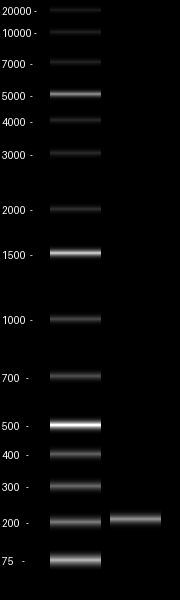

In [163]:
# Create a gel to see if the PCR and insertion worked
im = gel(
    [GeneRuler_1kb_plus,
     [pcr_product[0]], #The pcr product of the genome: is your construct in there?
    ])

im

#### Check the resulting metabolite consumption profiles
Now we are sure that the insert is there, we will run some experiments to check if we get the required phenotype. In this case we are interested in the metabolite consumption profile of glucose and glycerol.

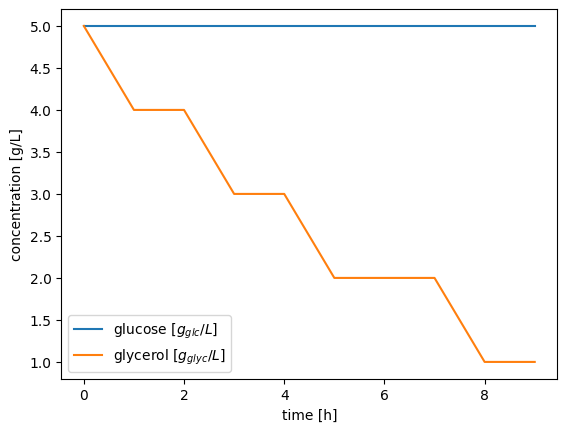

In [164]:
perform_batch_experiment(putida_genome, pcr_product)

## Additional material
Did you enjoy working with the concepts introduced in this seminar? If yes, we recommend the following resources:
- The Jupyter-book by [Elowitz and Bois](https://biocircuits.github.io/index.html) gives detailed treatment and further examples for different models of genetic circuits. 
- With the python package [pydna](https://github.com/BjornFJohansson/pydna), you cannot only do 'in silico' experiments like in this notebook, but you can also build your lab notebook in Python. They even provide a [web interface](http://pydna.pythonanywhere.com/), which allows you to design primers and do PCR.
- Marc Facciotti from the university of California has made a good [webpage](https://bio.libretexts.org/Courses/University_of_California_Davis/BIS_2A%3A_Introductory_Biology_(Britt)/02%3A_Face-2-Face/2.10%3A_Regulation_of_Gene_Expression) about the principles and patterns in the regulation of gene expression.

<hr>

## References

- Bintu, L., et al., Transcriptional regulation by the numbers: models, _Curr. Op. Genet. Dev._, 15, 116–124, 2005.([link](https://doi.org/10.1016/j.gde.2005.02.007))
- Milo, R., et al., Network motifs: Simple building blocks of complex networks, _Science_, 298, 824–827, 2002. ([link](https://doi.org/10.1126/science.298.5594.824))

<hr>

## Answer: truth table of the metabolism of glucose

glc | gly | cmet
:---:|:---:|:----------:
0 | 0 | 0
1 | 0 | 0
0 | 1 | 0
1 | 1 | 1